### **图片与子图**

matplotlib所绘制的图像位于图片（$Figure$）对象中。    
fig.add_subplot返回$Axes Subplot$对象，使用这些对象可以直接在其他空白子图上调用对象的实例方法进行绘图。

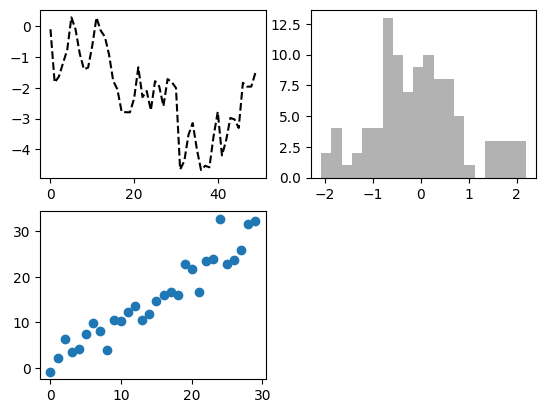

In [1]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
# 生成一个新图像
fig = plt.figure()
# 创建一个或多个子图
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)
ax1.plot(np.random.randn(50).cumsum(), 'k--')
ax2.hist(np.random.randn(100), bins=20, color='k', alpha=0.3)
ax3.scatter(np.arange(30), np.arange(30) + 3 * np.random.randn(30))

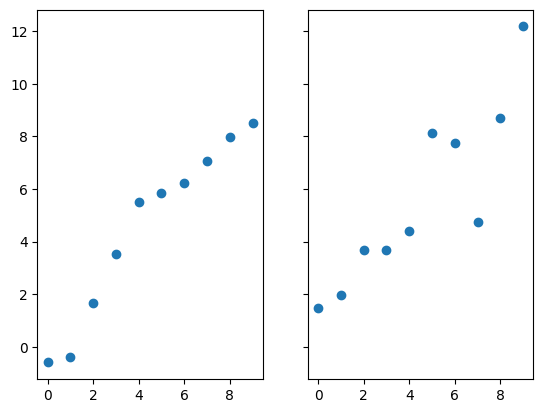

In [2]:
# 使用plt.subplots创建一个新的figure并且返回已生成的子图对象的Numpy数组
fig, axes = plt.subplots(1, 2, sharex=True, sharey=True)
axes[0].scatter(np.arange(10), np.arange(10) + 1 * np.random.randn(10))
axes[1].scatter(np.arange(10), np.arange(10) + 2 * np.random.randn(10))

当在相同的比例下进行数据对比时使用**sharex**与**sharey**使子图分别拥有相同的x轴或y轴非常有用

默认情况下，matplotlib会在子图之间留出一定的间隙，该间隙相对于图的高度与宽度进行指定，可以使用**subplots_adjust**方法更改间距

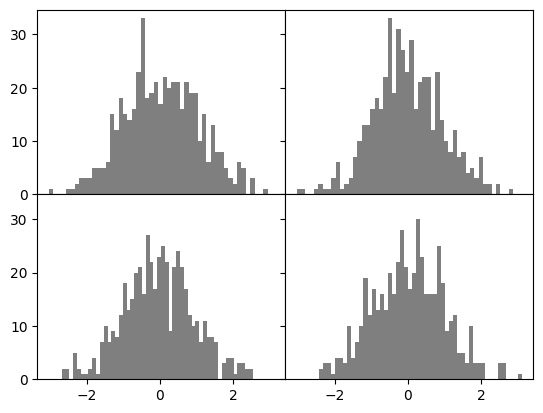

In [3]:
fig, axes = plt.subplots(2, 2, sharex=True, sharey=True)
for i in range(2):
    for j in range(2):
        axes[i, j].hist(np.random.randn(500), bins=50, color='k', alpha=0.5)
plt.subplots_adjust(wspace=0, hspace=0) #wspace与hspace分别控制图片宽度与高度的百分比作为图片中的间隙

matplotlib的主函数plot可以接收带有x,y轴的数组以及一系列可选的参数来指明颜色与形状

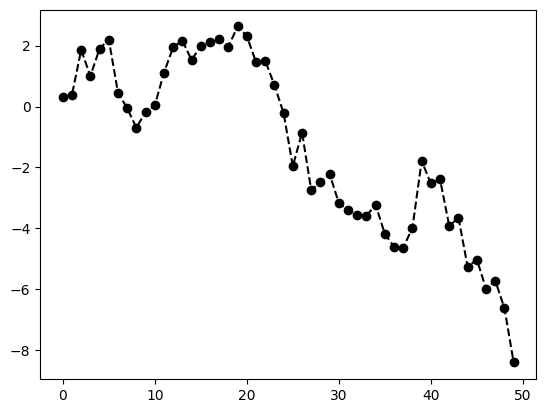

In [4]:
plt.plot(np.random.randn(50).cumsum(), 'ko--') # 创建一个带有点标记虚线连接的折线图
# 以上代码的显式写法如下
# plt.plot(np.random.randn(50).cumsum(), color='k', linestyle='--', marker='o')

需要改变x轴的刻度可以使用**set_xticks**与**set_xticklabels**，作用分别是在数据范围内设定刻度的位置与改变刻度的标签，并可以通过**set_xlabel**为x轴设置名称，**set_title**可以为子图设置一个标题，如果在plot中设置了**label**参数可以调用**ax.legend**或者**plt.legend**自动生成图例。

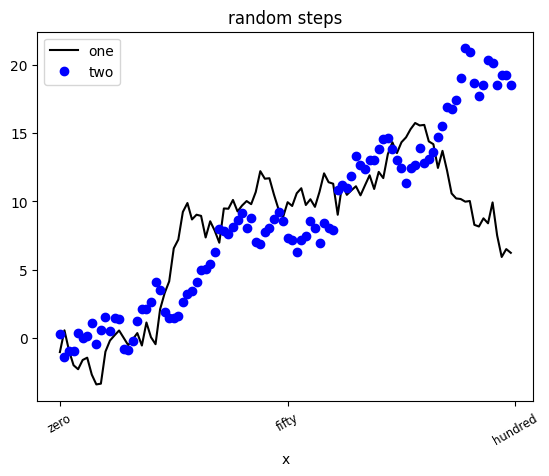

In [5]:
fig, ax = plt.subplots(1, 1)
ax.plot(np.random.randn(100).cumsum(), 'k', label='one')
ax.plot(np.random.randn(100).cumsum(), 'bo', label = 'two')
ax.set_xticks([0, 50, 100])
ax.set_xticklabels(['zero', 'fifty', 'hundred'], rotation=30, fontsize='small') # rotation控制标签的旋转角度，fontsize控制字体的大小
ax.set_xlabel('x')
ax.set_title('random steps')
ax.legend()

可以使用**text**，**arrow**，**annote**方法来为图像添加注释和文本

Text(0.5, 1.0, 'random steps with annotaation')

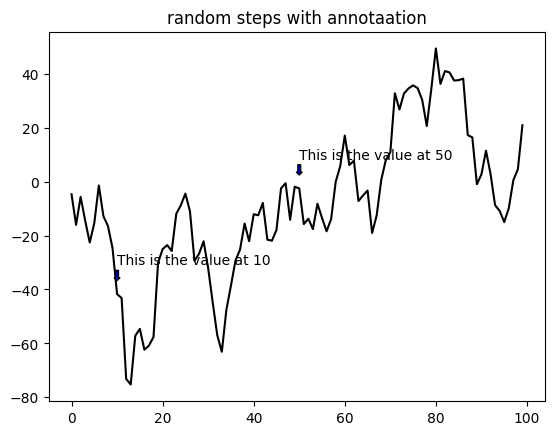

In [6]:
x = np.arange(100)
y = 10 * np.random.randn(100).cumsum()
plt, ax = plt.subplots(1, 1)
ax.plot(x, y, 'k-')
annotation = [
    (10, 'This is the value at 10'),
    (50, 'This is the value at 50')
]
for x, label in annotation:
    ax.annotate(label, xy=(x, y[x] + 5), 
                         xytext= (x, y[x] + 15),
                         arrowprops=dict(facecolor='blue', headwidth=4, width=2, headlength=2),
                         horizontalalignment='left',
                         verticalalignment='top')
ax.set_title('random steps with annotaation')

可以使用 **plt.savefig('filepath.png')** 将图片保存到文件，可选参数有**dpi**与**bbox_inches**作用分别是控制每英尺点数的分辨率与除去图片周围的空白部分（bbox_inches='tight'）